<a href="https://colab.research.google.com/github/brenrcarcao-dot/analysis-ladb_mobility_economy_2024/blob/main/S5_ladb_mobility_economy_project_student_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción

Como analista de datos, el objetivo fue **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Se trabajaron con datos reales de TomTom Traffic Index y OECD Cities, que se limpiaron, combinaron y analizaron para identificar en qué ciudades conviene invertir en infraestructura de transporte.


### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [ ]:
# importar librerías
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
# mostrar las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [ ]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo object cuando debería de ser datetime para poder ordenar, filtrar por fecha y agrupar por periodos sin errores
- La columna JamsCount debería ser integer debido a que muestra conteos totales de embotellamientos activos al momento del registro, no puede haber 0.5 embotellamiento
- No hay ningún dato ausente en las columnas, ya que todas ellas tienen 1,004,464 filas que equivalen al número total de filas en el df

In [ ]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, `PM2.5` y `Population` deberían ser de tipo float64 ya que son columnas que muestran medidas y con las que se debería de poder hacer cálculos
- No hay ningún dato ausente en las columnas, ya que todas ellas tienen 30 filas que equivalen al número total de filas en el df

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:
# Estandarizar los nombres de las columnas de traffic
#tu código aquí
traffic=traffic.rename(columns={"Country":"country","City":"city","UpdateTimeUTC":"update_time_utc","UpdateTimeUTCWeekAgo":"update_time_utc_week_ago","JamsDelay":"jams_delay","TrafficIndexLive":"traffic_index_live","JamsLengthInKms":"jams_length_kms","JamsCount":"jams_count","TrafficIndexWeekAgo":"traffic_index_week_ago","TravelTimeLivePer10KmsMins":"travel_time_live_per_10kms_mins","TravelTimeHistoricPer10KmsMins":"travel_time_hist_per_10kms_mins","MinsDelay":"mins_delay"})
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco=eco.rename(columns={"Year":"year","City":"city","Country":"country",'City GDP/capita':'city_gdp_capita','Unemployment %':'unemployment_pct',"PM2.5 (μg/m³)":"pm25",'Population (M)':'population_m'})
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce', utc=True)
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce', utc=True)

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype              
---  ------                           --------------    -----              
 0   country                          1004464 non-null  object             
 1   city                             1004464 non-null  object             
 2   update_time_utc                  1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                       1004464 non-null  float64            
 4   traffic_index_live               1004464 non-null  float64            
 5   jams_length_kms                  1004464 non-null  float64            
 6   jams_count                       1004464 non-null  float64            
 7   traffic_index_week_ago           1004464 non-null  float64            
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns, UTC]
 9   travel_time_live_per_10kms_mins  1004464 non-n

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
# eco['city_gdp_capita'] = ....astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['city_gdp_capita']=(eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float))
# eco['unemployment_pct'] = ...
eco['unemployment_pct'] =(eco['unemployment_pct'].astype("string").str.replace('%',' ').str.replace(',','.').astype(float))
# eco['population_m'] = ...
eco['population_m'] = (eco['population_m'].astype("string").str.replace(',','.').astype(float))
# Calcula la población total en unidades absolutas (Multiplica * 1000000)
# eco['population'] = ...
eco['population'] = eco['population_m']*1000000
# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
# Extraer el año de las fechas en update_time_utc
# traffic['year'] = ...
traffic['year']=traffic['update_time_utc'].dt.year
# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
# traffic_2024 = traffic[...].copy()
traffic_2024=traffic[traffic['year']==2024].copy()
# eco_2024 = ...
eco_2024=eco[eco['year']==2024].copy()
# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
lista_de_columnas = ['jams_delay', 'traffic_index_live', 'jams_length_kms', 'jams_count', 'mins_delay','travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']
traffic_city_year_2024 = (traffic_2024.groupby(['city', 'country', 'year'])[lista_de_columnas].agg('mean').reset_index())

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Momento de reflexión**

Ahora que ya tenemos los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuáles tienen el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?



In [ ]:
# tu código aquí
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es Ciudad de México


---

## 🧩Paso 5: Unir movilidad y economía


### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Seleccionamos solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usamos `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Unimos ambos DataFrames y definimos como **claves de unión** a `city` y `year`.
- Mantenemos solo las ciudades y años presentes en ambos datasets.
- Guardamos el resultado en una nueva variable llamada `merged` y mostramos las primeras 5 filas.


In [1]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
# traffic_2024_small = traffic_city_year_2024[ ... ].copy()
# eco_2024_small = ...
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()
# Unir datasets
merged = pd.merge(traffic_2024_small,eco_2024_small,on=['city','year'],how='inner')

# Mostrar las primeras 5 filas
# tu código aquí
merged.head(5)

NameError: name 'traffic_city_year_2024' is not defined


---

## 🧩Paso 6: Visualización y análisis de relaciones


### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usamos las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualizamos la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualizamos la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **comparamos ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Observamos y comentamos los patrones, valores extremos o posibles relaciones que identifiques.

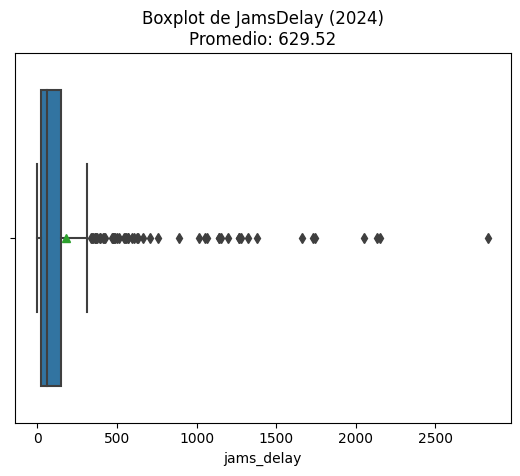

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
import seaborn as sns
import matplotlib.pyplot as plt
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
sns.boxplot(data=traffic_2024_small, x='jams_delay',showmeans=True)
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


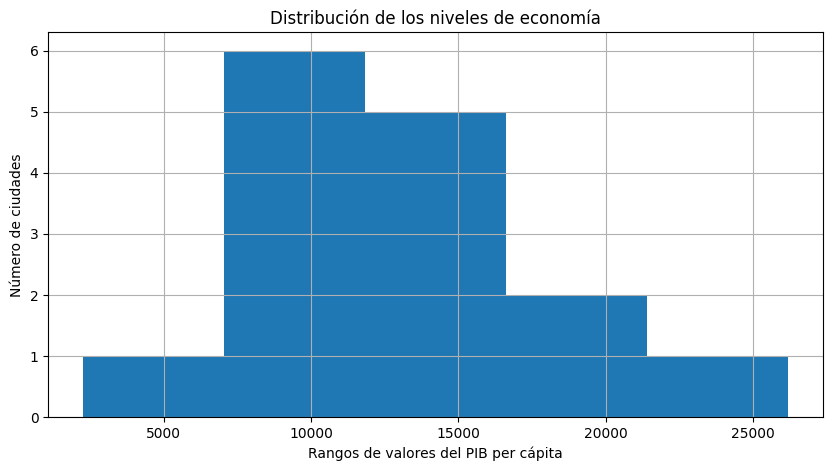

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)

import matplotlib.pyplot as plt
eco_2024_small['city_gdp_capita'].hist(bins=5,figsize=(10,5))
plt.title('Distribución de los niveles de economía')
plt.xlabel('Rangos de valores del PIB per cápita')
plt.ylabel('Número de ciudades')
plt.show()


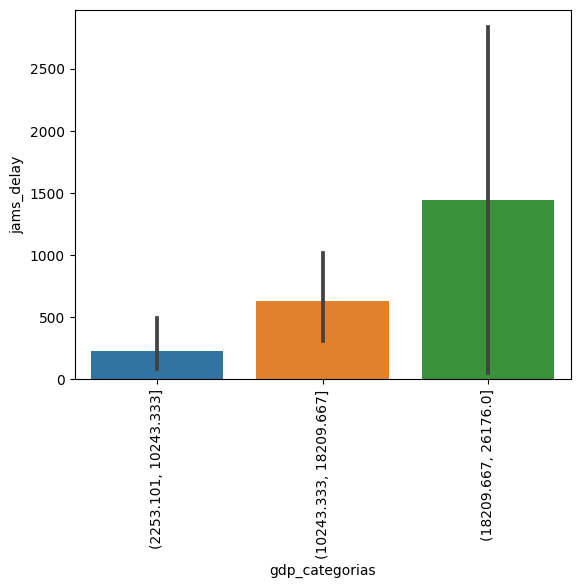

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])

merged['gdp_categorias']=pd.cut(merged['city_gdp_capita'], bins=3)
sns.barplot(data=merged, x='gdp_categorias', y='jams_delay')
plt.xticks(rotation=90)
plt.show()


Observamos que en la mayoría de los casos se ve una correlación clara. A mayor PIB per cápita, también hay más congestión.


---

## 🧩Paso 7: Exportar y documentar resultados


### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información.


---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  

- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.
  
- Este análisis explora la relación entre la movilidad urbana (congestión vehicular, tiempos de viaje) y la productividad económica (PIB per cápita) en 15 ciudades de América Latina. COn este análisis buscamos responder la pregunta central: ¿las ciudades más congestionadas son inherentemente menos productivas? Entender esto es crítico para priorizar inversiones en infraestructura de transporte que desbloquee capacidad económica en ciudades de alto potencial pero bajo rendimiento relativo.
  
**Cobertura de datos:**  

- Especifica los años analizados, número de ciudades y países incluidos.
  
- El análisis abarca 15 ciudades de 7 países latinoamericanos en 2024: Brasil (9 ciudades: São Paulo, Rio de Janeiro, Belo Horizonte, Brasilia, Curitiba, Porto Alegre, Fortaleza, Recife, Salvador), Colombia (Bogotá), Argentina (Buenos Aires), Perú (Lima), México (México City), Uruguay (Montevideo) y Chile (Santiago). Los datos combinan 7 variables de movilidad urbana del índice TomTom (congestión, tiempos de viaje, longitud de embotellamientos) con 4 indicadores económicos de la OECD (PIB per cápita, desempleo, contaminación, población).

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

  
- El flujo de análisis incluyó: (1) Exploración y limpieza — estandarización de formatos (conversión de decimales con coma a punto, tipos de datos numéricos). (2) Agregación por ciudad-año — consolidación de métricas de tráfico diarias en promedios anuales. (3) Integración de datasets — unión INNER entre variables de movilidad (TomTom) y economía (OECD) mediante identificador ciudad-año, resultando en 15 registros válidos. (4) Validaciones visuales y estadísticas —

**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.
- 1. La congestión no es causa directa de baja productividad
Al observar los datos ciudad por ciudad, vemos un patrón: las ciudades más grandes y económicamente dinámicas (México City con $21K PIB per cápita, São Paulo con $14.7K) tienen AMBAS cosas: la mayor congestión (2,833 y 1,729 minutos de retraso) Y altos ingresos per cápita. En contraste, ciudades pequeñas con baja congestión (Montevideo con 50 min de retraso) también tienen diferentes niveles de productividad.
Lo que esto sugiere: La congestión es más bien una consecuencia de que ciudades concentren población, empleo y actividad económica — no la causa de que sean improductivas. Sin embargo, hay excepciones críticas que desafían este patrón (ver Hallazgo 3).
- 2. Ciudades más congestionadas tienen tasas de desempleo más bajas. Ciudades como México City (desempleo 3.2%) y São Paulo (8.5%) tienen más congestión pero menos desempleo. Ciudades como Fortaleza, Salvador y Recife tienen menos congestión pero desempleo mayor (11-12%).
Lo que esto sugiere: No es que la congestión cree empleo. Más bien, ciudades con más oportunidades laborales atraen migrantes buscando trabajo → más habitantes → más vehículos → más tráfico. La congestión es un indicador visible de que hay mucha actividad económica en marcha.
  3. Outlier crítico — Santiago de Chile: baja productividad con congestión moderada-alta
Santiago presenta un patrón anómalo: tiene el PIB per cápita más bajo de todas ($2,277 USD, casi 6 veces menor que Buenos Aires que está a $18,117), pero no tiene la congestión más baja. De hecho, Santiago está en el medio-alto con 629.87 minutos de retraso.
Esto sugiere que Santiago podría estar atrapada en una dinámica diferente: genera congestión (probablemente por ser capital política y concentrador de servicios) sin convertirla en capacidad productiva equivalente. Requiere análisis institucional adicional.
- 4. Entre Bogotá, Lima y Buenos Aires — Bogotá es la ciudad prioritaria para intervención. Bogotá muestra el desbalance más agudo:

Congestión casi tan alta como Lima (1,141 vs 1,052 min),
PERO con PIB significativamente más bajo ($11.4K vs $13.5K)
Y con desempleo más alto (10% vs 6.5%)

Esto sugiere que la congestión en Bogotá es especialmente ineficiente: genera retrasos sin convertirlos en oportunidades económicas proporcionales. A diferencia de Lima y Buenos Aires donde los viajes largos y tiempos altos están asociados a mayores ingresos, Bogotá tiene un problema de congestión sin retorno económico.

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?
- 1. Inversión prioritaria — Bogotá (Colombia):

Bogotá reúne dos condiciones críticas: (a) congestión extrema sin retorno económico proporcional, (b) desempleo elevado que podría aliviarse con mejora en movilidad. Propuesta: diagnóstico de corredores de transporte críticos, evaluación de transporte público masivo (expansión de TransMilenio) y carriles dedicados para reducir jams_delay. Métrica de éxito: reducir jams_delay en 20% debería correlacionar con reducción de desempleo.
- 2. Caso especial — Santiago de Chile:

El PIB extremadamente bajo requiere investigación institucional diferenciada (¿es un error de datos OECD o refleja metodología distinta?). Si válido, Santiago necesita análisis de política económica más allá de transporte. Propuesta: validar fuente OECD antes de acción.

- 3. Montevideo y Buenos Aires como referencias:

Montevideo (Uruguay) y Buenos Aires tienen tasas de desempleo y PIB per cápita comparables o superiores, pero congestión significativamente menor. Propuesta: estudiar políticas de planificación urbana, distribución de empleo en área metropolitana y regulaciones de transporte; replicar en Bogotá y Lima.
